# Identificação NARX v4 (Multi-Step BPTT) (Melhores Práticas)
Neste notebook, aplicamos as melhorias discutidas para o modelo NARX:
1. Uso de múltiplos datasets de treino (iguais ao `node_v4.py`).
2. Redução das ordens `ny` e `nu` para capturar a dinâmica fundamental sem overfitting de ruído.
3. Arquitetura de rede mais compacta.
4. Concatenação adequada dos datasets.
5. Validação guiada pelo erro de Free-Run.
6. Bypass Linear na Arquitetura (ResNet).
7. Treinamento Multi-Step (BPTT) com horizonte H=10.


In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score

# Seed para reprodutibilidade
rseed = 42
np.random.seed(rseed)
torch.manual_seed(rseed)
np.set_printoptions(precision=3)

device = torch.device('cpu')
print(f"Using device: {device}")


Using device: cpu


## 1. Funções Auxiliares


In [10]:
def matReg(y, u, ny, nu):
    p = max(ny, nu) + 1
    (N, ) = y.shape
    (Nu, ) = u.shape

    if N != Nu:
        print('Dimensões inconsistentes')
        return (-1,-1)

    target = y[p-1:N]
    Phi = np.zeros((N-p+1, ny+nu))
    
    for i in range(ny):
        Phi[:, i] = y[p-i-2 : N-i-1]
    for i in range(nu):
        Phi[:, i+ny] = u[p-i-2 : N-i-1]

    return (target, Phi)

def freeRun(model, y, u, ny, nu, device):
    p = max(ny, nu) + 1
    (N, ) = y.shape

    yhat = np.zeros(N)
    yhat[:p-1] = y[:p-1] 

    for k in range(p, N+1):
        auxY = np.concatenate((yhat[(k-p):(k-1)], (0,)), axis=0)
        auxU = np.concatenate((u[(k-p):(k-1)], (0,)), axis=0)

        _, fr_input = matReg(auxY, auxU, ny, nu)
        
        tensor_input = torch.tensor(fr_input, dtype=torch.float32).to(device)
        yhat[k-1] = model.predict(tensor_input).item()
        
    return yhat[-(N-p+1):]


## 2. Carregamento e Preparação dos Múltiplos Datasets
Usamos os mesmos conjuntos de Treino e Validação do `node_v4.py`.
Também aplicamos o corte inicial/final para tirar os ruídos e a decimação por 2.


In [ ]:
from scipy.signal import decimate

def carregar_experimento(url, decimacao=2, start_idx=1300, end_idx=-1600):
    df = pd.read_csv(url)
    
    if 'u_pct' in df.columns:
        u_full = df['u_pct'].values
    else:
        u_full = df['motor_percent'].values
        
    y_full = df['angulo_deg'].values
    
    # Para y (sensor) - filtro anti-aliasing
    y_raw = decimate(y_full, decimacao, ftype='iir', zero_phase=True)
    # Para u (controle) - subsampling direto preserva degraus
    u_raw = u_full[::decimacao]
    
    u = u_raw[start_idx:end_idx]
    y = y_raw[start_idx:end_idx]
    return u, y

BASE2 = "https://raw.githubusercontent.com/FelipeEduardoMarcondes/SYSTEM-IDENTIFICATION-AERO/main/experimentos/"

"""
    "aprbs-1_0819_18-48.csv",
    "aprbs-2_0819_18-51.csv",
    "aprbs-neg-1_0819_18-54.csv",
    "multi-seno-1_0819_19-23.csv",
    "multi-seno-2_0819_18-59.csv",
    "multi-seno-2_0819_19-11.csv",
    "multi-seno-3_0819_19-19.csv",
    "seq-degraus-aprbs-2_0819_19-16.csv",
    "swept-sine-1_0819_19-02.csv",
"""
train_files = [
    "RODADA-2/chirp-1_0804_19-19.csv",
    "RODADA-2/multi-seno-2_0804_19-28.csv",
    "RODADA-2/seq-degraus-1_0804_19-09.csv",
    "RODADA-3/multi-seno-1_0807_16-57.csv",
    "RODADA-3/multi-seno-2_0807_17-13.csv",
    "RODADA-3/seq-degraus-1_0807_16-38.csv",
    "RODADA-3/seq-degraus-aprbs-2_0807_17-23.csv",
    "RODADA-3/seq-dragus-aprbs_0807_16-50.csv"
]

val_files = [

    "RODADA-2/multi-seno-1_0804_19-06.csv",
    "RODADA-2/seq-degraus-2_0804_19-38.csv",
    "RODADA-2/multi-seno-3_0804_19-44.csv",
    "RODADA-2/seq-degraus-1_0804_19-12.csv"
]

scaler_u = MinMaxScaler(feature_range=(-1, 1))
scaler_y = MinMaxScaler(feature_range=(-1, 1))
scaler_u.fit(np.array([[-100], [100]]))
scaler_y.fit(np.array([[-180], [180]]))

print("Carregando e processando conjuntos de TREINO...")
u_train_list, y_train_list = [], []
for f in train_files:
    u, y = carregar_experimento(BASE2 + f, decimacao=2, start_idx=700, end_idx=-900)
    u_norm = scaler_u.transform(u.reshape(-1, 1)).flatten()
    y_norm = scaler_y.transform(y.reshape(-1, 1)).flatten()
    u_train_list.append(u_norm)
    y_train_list.append(y_norm)

print("Carregando e processando conjuntos de TESTE/VALIDAÇÃO...")
u_val_list, y_val_list = [], []
for f in val_files:
    u, y = carregar_experimento(BASE2 + f, decimacao=2, start_idx=700, end_idx=-900)
    u_norm = scaler_u.transform(u.reshape(-1, 1)).flatten()
    y_norm = scaler_y.transform(y.reshape(-1, 1)).flatten()
    u_val_list.append(u_norm)
    y_val_list.append(y_norm)


Carregando e processando conjuntos de TREINO...
Carregando e processando conjuntos de TESTE/VALIDAÇÃO...


## Visualização dos Conjuntos de Treino
Abaixo estão os gráficos da variável de saída (ângulo) para cada um dos 9 conjuntos de treinamento.


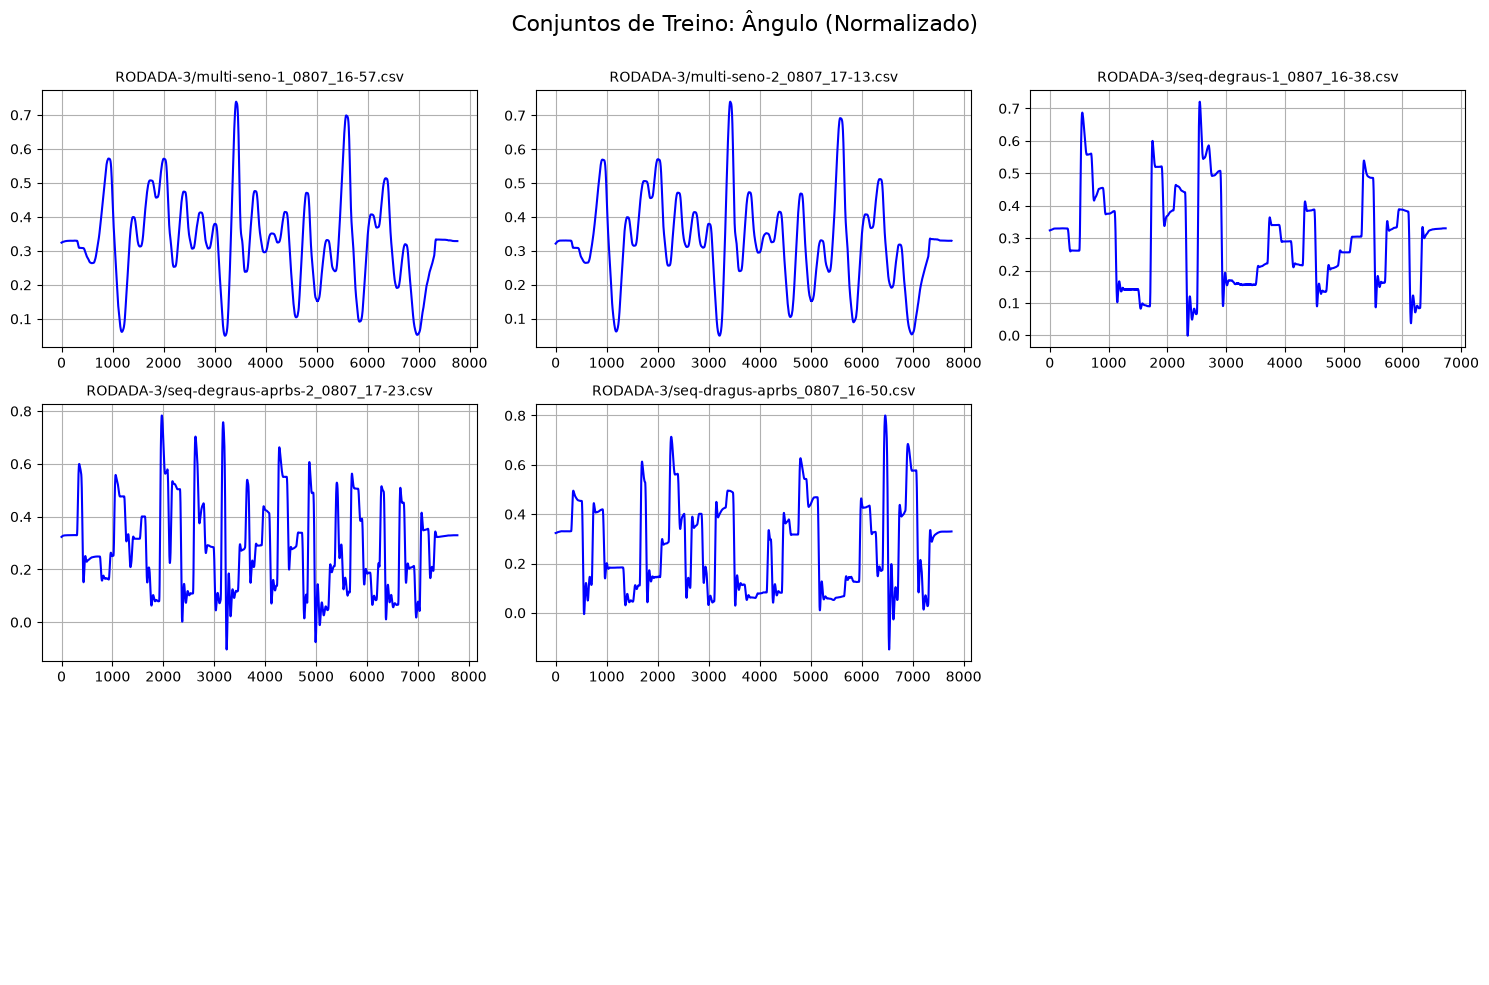

In [12]:
fig, axs = plt.subplots(3, 3, figsize=(15, 10))
fig.suptitle('Conjuntos de Treino: Ângulo (Normalizado)', fontsize=16)

for i, ax in enumerate(axs.flatten()):
    if i < len(y_train_list):
        ax.plot(y_train_list[i], color='blue')
        ax.set_title(train_files[i], fontsize=10)
        ax.grid(True)
    else:
        ax.axis('off')

plt.tight_layout()
plt.subplots_adjust(top=0.90)
plt.show()


## 3. Matrizes de Regressão e Tensores
Geramos a matriz regressora separadamente para CADA dataset e depois as concatenamos.
Isto evita que o final de um experimento seja usado para prever o início do outro experimento.


In [13]:
ny = 30
nu = 50
H = 10 # Horizonte Multi-Step

import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader

def make_bptt_windows(y, u, ny, nu, H):
    p_start = max(ny, nu)
    p_end = len(y) - H + 1
    Y_past_list, Y_target_list, U_seq_list = [], [], []
    for p in range(p_start, p_end):
        # Ordem cronológica
        Y_past_list.append(y[p - ny : p])
        Y_target_list.append(y[p : p + H])
        U_seq_list.append(u[p - nu : p + H - 1])
    return np.array(Y_past_list), np.array(Y_target_list), np.array(U_seq_list)

Y_past_all, Y_target_all, U_seq_all = [], [], []
for y_n, u_n in zip(y_train_list, u_train_list):
    yp, yt, us = make_bptt_windows(y_n, u_n, ny, nu, H)
    Y_past_all.append(yp)
    Y_target_all.append(yt)
    U_seq_all.append(us)

Y_past_t = torch.tensor(np.concatenate(Y_past_all, axis=0), dtype=torch.float32).to(device)
Y_target_t = torch.tensor(np.concatenate(Y_target_all, axis=0), dtype=torch.float32).to(device)
U_seq_t = torch.tensor(np.concatenate(U_seq_all, axis=0), dtype=torch.float32).to(device)

dataset = TensorDataset(Y_past_t, U_seq_t, Y_target_t)
dataloader = DataLoader(dataset, batch_size=64, shuffle=True)



## 4. Arquitetura da Rede e Treinamento


In [14]:
class NARXModel(nn.Module):
    def __init__(self, ny, nu, hidden_dim1=128, hidden_dim2=64, dropout=0.1):
        super().__init__()
        self.ny = ny
        self.nu = nu
        self.linear_bypass = nn.Linear(ny + nu, 1)
        self.net = nn.Sequential(
            nn.Linear(ny + nu, hidden_dim1),
            nn.Tanh(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim1, hidden_dim2),
            nn.Tanh(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim2, 1)
        )
    
    def forward(self, x):
        return self.linear_bypass(x) + self.net(x)
        
    def multi_step_forward(self, y_past, u_seq, H):
        # y_past: (B, ny) in chronological order
        # u_seq: (B, nu + H - 1) in chronological order
        y_preds = []
        y_buffer = y_past.clone()
        for h in range(H):
            y_in = y_buffer[:, -self.ny:]
            u_in = u_seq[:, h : h + self.nu]
            x = torch.cat([y_in, u_in], dim=1)
            pred = self.forward(x) # (B, 1)
            y_preds.append(pred)
            y_buffer = torch.cat([y_buffer, pred], dim=1)
        return torch.cat(y_preds, dim=1) # (B, H)



In [15]:
model = NARXModel(ny, nu, 256, 128).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5, factor=0.5)

epochs = 1000
best_val_loss = float('inf')
patience_counter = 0
patience_limit = 200

# Validacao Free-Run no primeiro dataset de validacao
y_val_fr = y_val_list[0]
u_val_fr = u_val_list[0]
H_val = len(y_val_fr) - max(ny, nu)
yp_val, yt_val, us_val = make_bptt_windows(y_val_fr, u_val_fr, ny, nu, H_val)

Yp_val_t = torch.tensor(yp_val[0:1], dtype=torch.float32).to(device) 
Us_val_t = torch.tensor(us_val[0:1], dtype=torch.float32).to(device)
Yt_val_t = torch.tensor(yt_val[0:1], dtype=torch.float32).to(device)

for epoch in range(epochs):
    model.train()
    epoch_loss = 0.0
    for y_past, u_seq, targets in dataloader:
        optimizer.zero_grad()
        # Aqui o modelo prevê a trajetória de H=10 passos
        outputs = model.multi_step_forward(y_past, u_seq, H)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        
    epoch_loss /= len(dataloader)
    
    # Validação via Free-Run Completo no dataset de validacao
    model.eval()
    if (epoch + 1) % 5 == 0 or epoch == 0:
        with torch.no_grad():
            preds_val = model.multi_step_forward(Yp_val_t, Us_val_t, H_val)
            val_loss = criterion(preds_val, Yt_val_t).item()
        
        scheduler.step(val_loss)
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), 'best_narx.pth')
            patience_counter = 0
        else:
            patience_counter += 5
            
        print(f'Epoch {epoch+1:3d}/{epochs} | Train Loss (Multi-Step H={H}): {epoch_loss:.5f} | Val Loss (Free-Run): {val_loss:.5f} | Best Loss: {best_val_loss:.5f}')
        
        if patience_counter >= patience_limit:
            print(f"Early stopping na epoch {epoch+1}")
            break



Epoch   1/1000 | Train Loss (Multi-Step H=10): 0.00129 | Val Loss (Free-Run): 0.02796 | Best Loss: 0.02796
Epoch   5/1000 | Train Loss (Multi-Step H=10): 0.00021 | Val Loss (Free-Run): 0.05315 | Best Loss: 0.02796
Epoch  10/1000 | Train Loss (Multi-Step H=10): 0.00015 | Val Loss (Free-Run): 0.01379 | Best Loss: 0.01379
Epoch  15/1000 | Train Loss (Multi-Step H=10): 0.00037 | Val Loss (Free-Run): 0.01004 | Best Loss: 0.01004
Epoch  20/1000 | Train Loss (Multi-Step H=10): 0.00010 | Val Loss (Free-Run): 0.00889 | Best Loss: 0.00889
Epoch  25/1000 | Train Loss (Multi-Step H=10): 0.00007 | Val Loss (Free-Run): 0.00880 | Best Loss: 0.00880
Epoch  30/1000 | Train Loss (Multi-Step H=10): 0.00005 | Val Loss (Free-Run): 0.01759 | Best Loss: 0.00880
Epoch  35/1000 | Train Loss (Multi-Step H=10): 0.00004 | Val Loss (Free-Run): 0.00585 | Best Loss: 0.00585
Epoch  40/1000 | Train Loss (Multi-Step H=10): 0.00004 | Val Loss (Free-Run): 0.01811 | Best Loss: 0.00585
Epoch  45/1000 | Train Loss (Multi-St

## 5. Avaliação Free-Run no conjunto de Validação


--- FREE-RUN NOS DATASETS DE TESTE ---
Dataset: RODADA-2/chirp-1_0804_19-19.csv
  R2: 0.6791 | RMSE: 10.55 graus


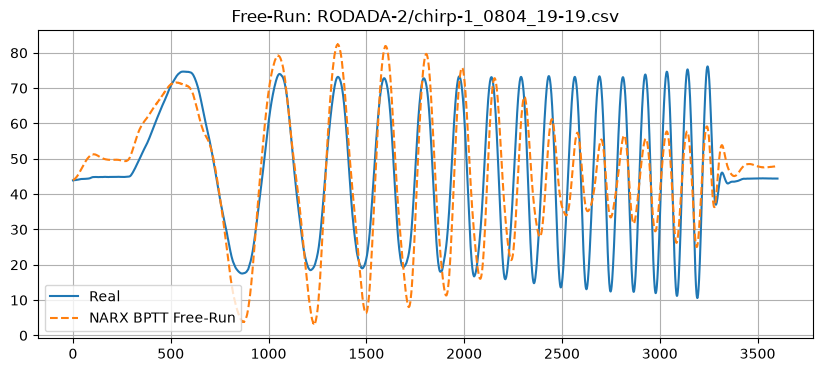

Dataset: RODADA-2/multi-seno-2_0804_19-28.csv
  R2: 0.5309 | RMSE: 15.20 graus


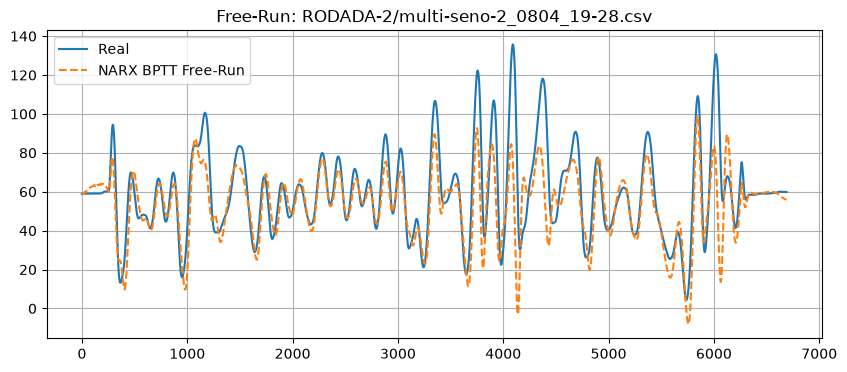

Dataset: RODADA-2/seq-degraus-1_0804_19-09.csv
  R2: 0.7301 | RMSE: 11.29 graus


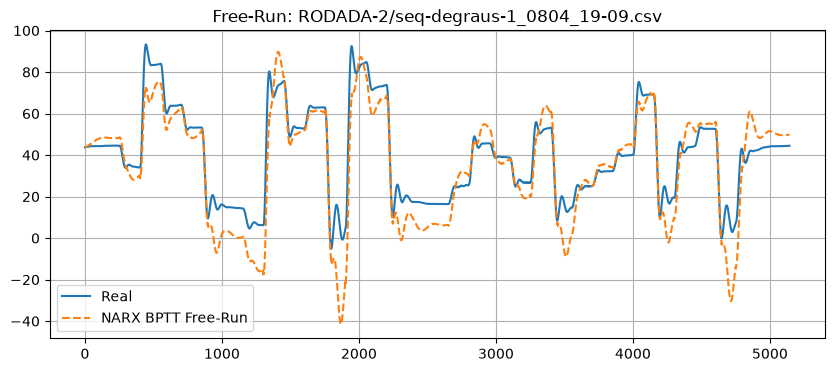

Dataset: RODADA-2/multi-seno-1_0804_19-06.csv
  R2: 0.7034 | RMSE: 9.83 graus


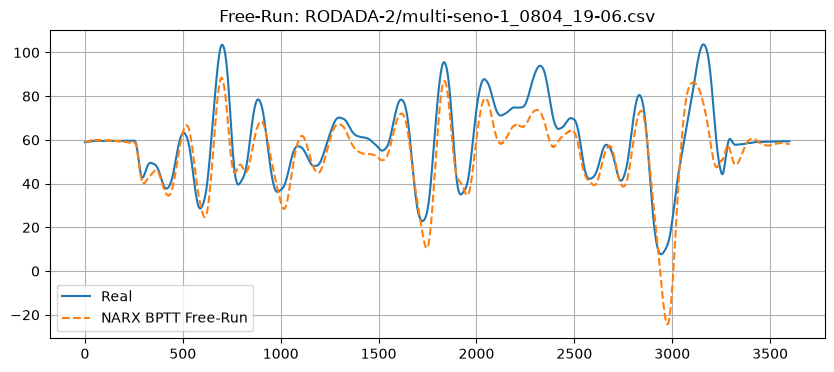

Dataset: RODADA-2/seq-degraus-2_0804_19-38.csv
  R2: 0.7088 | RMSE: 14.05 graus


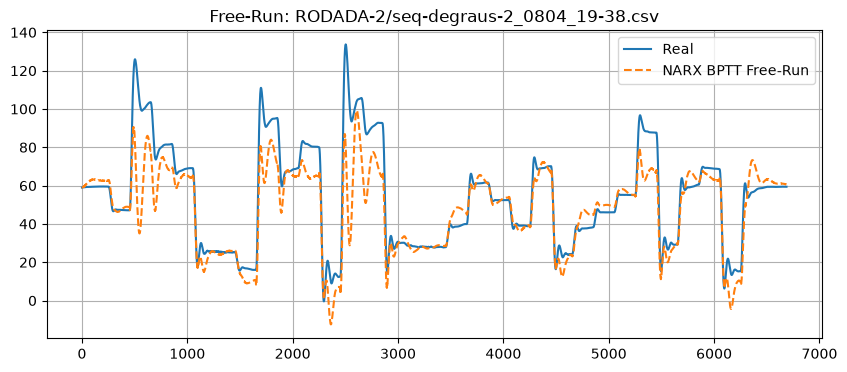

Dataset: RODADA-2/multi-seno-3_0804_19-44.csv
  R2: 0.5716 | RMSE: 15.58 graus


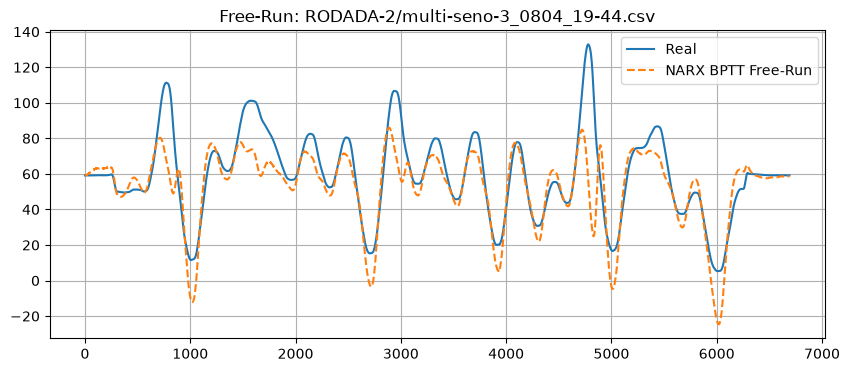

Dataset: RODADA-2/seq-degraus-1_0804_19-12.csv
  R2: 0.7356 | RMSE: 11.16 graus


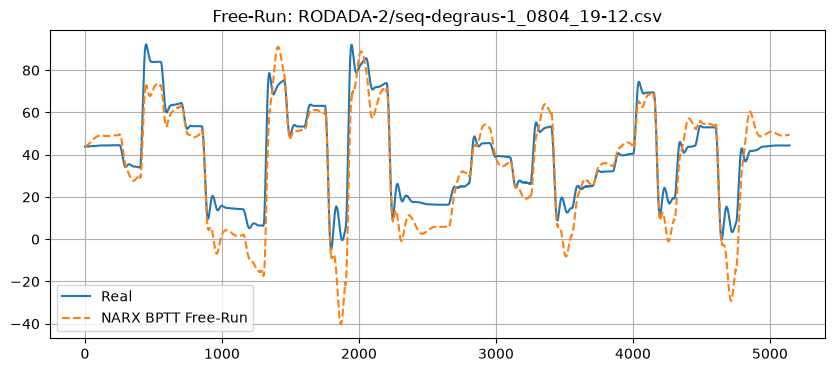

In [16]:
print("--- FREE-RUN NOS DATASETS DE TESTE ---")
model.load_state_dict(torch.load('best_narx.pth'))

for i, (y_n, u_n, file_name) in enumerate(zip(y_val_list, u_val_list, val_files)):
    H_test = len(y_n) - max(ny, nu)
    yp_test, yt_test, us_test = make_bptt_windows(y_n, u_n, ny, nu, H_test)
    
    if len(yp_test) == 0:
        continue
        
    Yp_t = torch.tensor(yp_test[0:1], dtype=torch.float32).to(device)
    Us_t = torch.tensor(us_test[0:1], dtype=torch.float32).to(device)
    
    model.eval()
    with torch.no_grad():
        y_test_pred0 = model.multi_step_forward(Yp_t, Us_t, H_test).cpu().numpy().flatten()
    
    y_real_eval = yt_test[0]
    
    # Desfaz a normalizacao
    y_real_original = scaler_y.inverse_transform(y_real_eval.reshape(-1, 1)).flatten()
    y_pred_original = scaler_y.inverse_transform(y_test_pred0.reshape(-1, 1)).flatten()
    
    r2 = r2_score(y_real_original, y_pred_original)
    rmse = np.sqrt(np.mean((y_real_original - y_pred_original)**2))
    
    print(f"Dataset: {file_name}")
    print(f"  R2: {r2:.4f} | RMSE: {rmse:.2f} graus")
    
    plt.figure(figsize=(10,4))
    plt.plot(y_real_original, label='Real')
    plt.plot(y_pred_original, label='NARX BPTT Free-Run', linestyle='dashed')
    plt.title(f'Free-Run: {file_name}')
    plt.legend()
    plt.grid()
    plt.show()

